<br>

# **3.0. Modeling - LogisticRegression**:

> 3.1. **Baseline Model: Dummy Classifier** <br>
> 3.2. **Bayesian Optimization (BayesSearchCV)** <br>
> 3.3. **Training the Model - Fit Logistic Regression** <br>
> 3.4. **Predict & Evaluate** <br>
> 3.5. **Classification Report & Confusion Matrix** <br>
> 3.6. **Probability Calibration** <br>
> 3.7. **Kolmogorov-Smirnov (KS) Statistics** <br>
> 3.8. **Expected Cost-Function** <br>
> 3.9. **Credit Scorecard** <br>
> 3.10. **PCA 2D Visualization** <br>
> 3.11. **LogReg + BorderlineSMOTE**

<br>

In [1]:
# Libraries
import pandas as pd
import numpy as np

# Logging
import logging
import time

# Joblib
import joblib

# CPU Cores & System
import os
import sys

if os.getcwd().endswith('notebooks'):
    %cd ..

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

/home/gontommuhammad/credit_risk_modeling


In [2]:
from src.utils import deserialize_data

# X set:
X_train_lr = deserialize_data('data/processed/logreg/X_train_lr.pkl')
X_valid_lr = deserialize_data('data/processed/logreg/X_valid_lr.pkl')
X_test_lr  = deserialize_data('data/processed/logreg/X_test_lr.pkl')

# y set:
y_train = deserialize_data('data/interim/y_train.pkl')
y_valid = deserialize_data('data/interim/y_valid.pkl')
y_test  = deserialize_data('data/interim/y_test.pkl')

Data successfully deserialized from data/processed/logreg/X_train_lr.pkl
Data successfully deserialized from data/processed/logreg/X_valid_lr.pkl
Data successfully deserialized from data/processed/logreg/X_test_lr.pkl
Data successfully deserialized from data/interim/y_train.pkl
Data successfully deserialized from data/interim/y_valid.pkl
Data successfully deserialized from data/interim/y_test.pkl


In [3]:
X_train_lr.info()

<class 'pandas.DataFrame'>
Index: 84764 entries, 1006175 to 1367503
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   annual_inc_woe          84764 non-null  float64
 1   credit_age_years_woe    84764 non-null  float64
 2   dti_woe                 84764 non-null  float64
 3   emp_length_ordinal_woe  84764 non-null  float64
 4   has_derogatory_woe      84764 non-null  float64
 5   home_ownership_woe      84764 non-null  float64
 6   inq_last_6mths_woe      84764 non-null  float64
 7   loan_to_income_woe      84764 non-null  float64
 8   open_acc_ratio_woe      84764 non-null  float64
 9   purpose_woe             84764 non-null  float64
 10  revol_util_woe          84764 non-null  float64
 11  term_woe                84764 non-null  float64
dtypes: float64(12)
memory usage: 8.4 MB


In [4]:
RANDOM_STATE = 42

<br>

---
### **Split Data: for Calibration Set:**

In [5]:
print(f"X_train shape: {X_train_lr.shape}, y_train shape: {y_train.shape}")

X_train shape: (84764, 12), y_train shape: (84764,)


In [6]:
TRAIN_CAL_SIZE = 10 / 90

from src.utils import split_train_test
X_train_lr, X_train_cal, y_train, y_train_cal = split_train_test(
    X_train_lr, 
    y_train,
    test_size=TRAIN_CAL_SIZE, 
    stratify=y_train,
    seed=RANDOM_STATE
)

In [7]:
print(f"X_train shape: {X_train_lr.shape}, y_train shape: {y_train.shape}")

X_train shape: (75345, 12), y_train shape: (75345,)


In [8]:
print(f"X_train cal shape: {X_train_cal.shape}, y_train cal shape: {y_train_cal.shape}")

X_train cal shape: (9419, 12), y_train cal shape: (9419,)


<br>

---
### **Import Metrics from Scikit Learn:**

In [9]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, log_loss, 
    matthews_corrcoef, classification_report, confusion_matrix, balanced_accuracy_score, 
    average_precision_score, brier_score_loss, precision_recall_curve, accuracy_score
)

<br>

---
## **3.1. Baseline Model: Dummy Classifier**:

In [10]:
from sklearn.dummy import DummyClassifier
# Create an object
dummy_clf = DummyClassifier(
    strategy='most_frequent',
    random_state=RANDOM_STATE
)
# Perform a fit, for y_train data only
dummy_clf.fit(
    X=X_train_lr, 
    y=y_train
)

DummyClassifier(random_state=42, strategy='most_frequent')

In [11]:
# Predict
y_pred_dummy = dummy_clf.predict(X_train_lr)

In [12]:
# Confusion matrix
confusion_matrix(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# [[tn, fp]]
# [[fn, tp]]

array([[63862,     0],
       [11483,     0]])

In [13]:
# Accuracy score
accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# Same as the largest class proportion

0.8475943990974849

**BASELINE PRIOR CLASS PROBABILITY**
- Find the probability of each class appearing
- Find the proportion of each class appearing in the training data
- Find the total odds of the class appearing based on the prior probability

In [14]:
print(f"y_train  :", y_train.value_counts(normalize=True))
print(f'y_valid  :', y_valid.value_counts(normalize=True))
print(f'y_test   :', y_test.value_counts(normalize=True))

y_train  : target
0    0.847594
1    0.152406
Name: proportion, dtype: float64
y_valid  : target
0    0.847584
1    0.152416
Name: proportion, dtype: float64
y_test   : target
0    0.860549
1    0.139451
Name: proportion, dtype: float64


In [15]:
# Odds of guessing minority correct:
proba_minority = 0.225043
proportion_minority = y_train.value_counts(normalize=True)[1]

odds_minority = proba_minority * proportion_minority
odds_minority

np.float64(0.034297813643904704)

In [16]:
# Odds of guessing majority correct:
proba_majority = 0.774957
proportion_majority = y_train.value_counts(normalize=True)[0]

odds_majority = proba_majority * proportion_majority
odds_majority

np.float64(0.6568492127413896)

In [17]:
# Odds total
odds_minority + odds_majority

np.float64(0.6911470263852943)

In [18]:
# Create an object
dummy_clf = DummyClassifier(
    strategy='stratified',
    random_state=RANDOM_STATE
)
# Perform a fit, for y_train data only
dummy_clf.fit(
    X=X_train_lr,
    y=y_train
)

DummyClassifier(random_state=42, strategy='stratified')

In [19]:
# Predict
y_pred_dummy = dummy_clf.predict(X_train_lr)

In [20]:
# Display confusion matrix
confusion_matrix(
    y_true=y_train,
    y_pred=y_pred_dummy
)
# [[tn, fp]]
# [[fn, tp]]

array([[54142,  9720],
       [ 9794,  1689]])

In [21]:
# Check accuracy
accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)

0.7410047116596987

In [22]:
# Balanced accuracy
balanced_accuracy_score(
    y_true=y_train,
    y_pred=y_pred_dummy
)

np.float64(0.4974419050234082)

In [23]:
# Calculate performance metrics
precision = precision_score(
    y_train, 
    y_pred_dummy, 
    pos_label=1, 
    zero_division=0
)
recall = recall_score(
    y_train, 
    y_pred_dummy, 
    pos_label=1
)
f1 = f1_score(
    y_train, 
    y_pred_dummy, 
    average='weighted'
)
roc_auc = roc_auc_score(
    y_train, 
    dummy_clf.predict_proba(X_train_lr)[:, 1]
)
# Print the results
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Precision : 0.1480
Recall    : 0.1471
F1 Score  : 0.7407
ROC AUC   : 0.4974


In [24]:
# Buat weight class
n_samples = len(y_train)
n_classes = len(y_train.value_counts())
n_samples_j = y_train.value_counts()

class_weight = n_samples / (n_classes * n_samples_j)
class_weight

# We give more weight to class 1

target
0    0.589905
1    3.280719
Name: count, dtype: float64

<br>

---
## **3.2. Bayesian Optimization (BayesSearchCV)**:

In [25]:
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt.space import Real, Integer, Categorical
from tqdm.auto import tqdm
from joblib import parallel_backend

In [26]:
# # ── Search Space ───────────────────────────────────────────────────────────
# # Effective dimension: 2D continuous.
# # ElasticNet includes L1 (l1_ratio=1.0) and L2 (l1_ratio=0.0) as boundary cases 
# # — no expressivity loss compared to separate penalty search, without the risk of conditional constraint violation.
# search_spaces = {
#     'C':         Real(1e-4, 1e3, prior='log-uniform'),
#     'l1_ratio':  Real(0.0, 1.0),   # l1_ratio=1 ≡ L1; l1_ratio=0 ≡ L2
# }

# # ── Locked Estimator ───────────────────────────────────────────────────────
# lr_estimator = LogisticRegression(
#     # penalty and solver MUST be locked together:
#     # 'elasticnet' is only valid with 'saga'; other solvers are not supported.
#     # Include solver as a search parameter with penalty='elasticnet'
#     # will always result in a ValueError for solvers other than saga.
#     penalty='elasticnet',
#     solver='saga',
#     # SAGA requires more iterations than lbfgs for convergence on large datasets; 
#     # 2000 is safe for ~155K training samples.
#     max_iter=2000,  
#     # `class_weight` is locked to None: consistent with XGBoost (scale_pos_weight) and 
#     # CatBoost (auto_class_weights) decisions; imbalance is handled via threshold optimization.
#     class_weight=None,
#     # Parallelism is delegated to BayesSearchCV (n_jobs=-1)
#     n_jobs=-1, 
#     random_state=42,
# )

# # ── BayesSearchCV ──────────────────────────────────────────────────────────
# bayes_search = BayesSearchCV(
#     estimator=lr_estimator,
#     search_spaces=search_spaces,
#     n_iter=40,           # Capable of continuous 2D; 60 gives diminishing returns
#     cv=StratifiedKFold(
#         n_splits=6,
#         shuffle=True,
#         random_state=RANDOM_STATE,
#     ),
#     scoring='neg_log_loss',
#     n_jobs=1,
#     random_state=RANDOM_STATE,
#     refit=True,
#     return_train_score=True,
#     verbose=0,
# )

# # Run BayesSearchCV
# # Setup Logging to file
# for handler in logging.root.handlers[:]:
#     logging.root.removeHandler(handler)
    
# logging.basicConfig(
#     level=logging.INFO, 
#     filename='bayes_search.log', 
#     filemode='w', 
#     format='%(asctime)s - %(message)s'
# )
# # Custom Callback for Progress and Logging
# class TqdmProgressCallback:
#     def __init__(self, total_iter):
#         self.total_iter = total_iter
#         self.current_iter = 0
#         self.pbar = tqdm(
#             total=total_iter, 
#             desc="BayesSearch Iterations", 
#             unit="iter"
#         )
#         self.logger = logging.getLogger()
        
#     def __call__(self, result):
#         # Global iteration counter
#         self.current_iter += 1
        
#         # Using logging.getLogger() directly inside the scope 
#         # is safer to avoid pickling the global variable 'logger'
#         self.logger.info(
#             f"Iteration {self.current_iter}/{self.total_iter}: "
#             f"Parameters {result.x}, "
#             f"Score {result.fun}"
#         )
        
#         # Update progress bar
#         self.pbar.update(1)

#         # Continue optimization
#         return False

#     def close(self):
#         self.pbar.close()

#     # --- Prevent PicklingError ---
#     def __getstate__(self):
#         # When it is going to be pickled to the worker,
#         # we remove 'pbar' from the state that is sent
#         state = self.__dict__.copy()
#         state.pop("pbar", None)
#         return state

#     def __setstate__(self, state):
#         # When received by the worker (unpickled), set pbar to `None`
#         self.__dict__.update(state)
#         self.pbar = None
        

# # Initialize progress callback
# progress_callback = TqdmProgressCallback(
#     total_iter=bayes_search.n_iter
# )
# # Attach callback to BayesSearchCV
# logging.getLogger().info(f"Starting BayesSearchCV...")
# bayes_search.fit(
#     X_train_lr, 
#     y_train,
#     callback=progress_callback
# )

# # Close progress bar
# progress_callback.close()

# # Showing the best parameters
# best_params = bayes_search.best_params_
# print(f"Best parameters:", best_params)

<br>

---
## **3.3. Training the Model - Fit Logistic Regression:**

In [27]:
# Import library
from sklearn.linear_model import LogisticRegression

In [28]:
# logreg = LogisticRegression(
#     C=0.38461013019343815,
#     class_weight=None,
#     l1_ratio=0.4754992118174114,
#     max_iter=2000,
#     penalty='elasticnet',
#     random_state=RANDOM_STATE,
#     solver='saga'
# )
# logreg.fit(X_train_lr, y_train)

logreg = LogisticRegression(
    C=0.496024651248498,
    class_weight=None,
    l1_ratio=0.0,
    max_iter=2000,
    penalty='elasticnet',
    random_state=RANDOM_STATE,
    solver='saga'
)
logreg.fit(X_train_lr, y_train)

LogisticRegression(C=0.496024651248498, l1_ratio=0.0, max_iter=2000,
                   penalty='elasticnet', random_state=42, solver='saga')


---
## **3.4. Predict & Evaluate**

<br>

### **F1 Threshold**: 

F1 Threshold: 0.1472


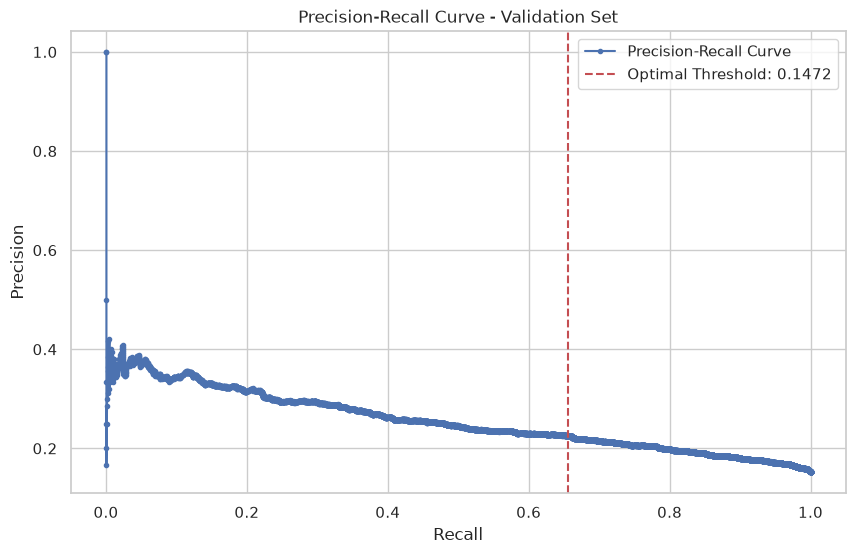

In [29]:
# PR curve only in Validation Set
precisions, recalls, thresholds = precision_recall_curve(
    y_valid,
    logreg.predict_proba(X_valid_lr)[:, 1]
)

# Align arrays
precisions_t = precisions[:-1]
recalls_t = recalls[:-1]

# F1 per threshold
f1_scores = np.where(
    (precisions_t + recalls_t) > 0,
    2 * precisions_t * recalls_t / (precisions_t + recalls_t),
    0
)
optimal_idx = np.argmax(f1_scores)
f1_threshold = thresholds[optimal_idx]

print(f"F1 Threshold: {f1_threshold:.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label=f"Precision-Recall Curve")
plt.axvline(recalls[optimal_idx], color='r', linestyle='--', label=f"Optimal Threshold: {f1_threshold:.4f}")
plt.xlabel(f"Recall")
plt.ylabel(f"Precision")
plt.title(f"Precision-Recall Curve - Validation Set")
plt.legend()
plt.show()

<br>

### **Cost-based Threshold**:

In [30]:
# Economic parameters:
c_fn = 8_250_000.0   # Cost False Negative: EAD * LGD = 15m * 0.55
c_fp = 2_700_000.0   # Cost False Positive: EAD * spread * duration = 15m * 0.09 * 2

"""
The threshold that minimizes: 
    
E[C(tau)] = c_fn * P(y=1) * FNR(tau) + c_fp * P(y=0) * FPR(tau).

The only criterion that is genuinely independent of F1 and Youden's 
because it is based on the economic objective function, 
not statistical discrimination or precision-recall.
"""

from src.helpers import find_best_cost_threshold

# ── RUN ──
optimal_cost_threshold, optimal_cost = find_best_cost_threshold(
    y_true=y_valid, 
    y_proba=logreg.predict_proba(X_valid_lr)[:, 1],
    c_fn=c_fn, c_fp=c_fp
)
print(f"Optimal Cost-based Threshold: {optimal_cost_threshold:.4f}; Optimal Cost: {optimal_cost:.4f}")

Optimal Cost-based Threshold: 0.2352; Optimal Cost: 1174957.5311


<br>

**Function to Evaluate Modelt**:

In [31]:
def evaluate_model(
    model, 
    X, y, 
    model_name, 
    split_set, 
    threshold=None):
    """
    Evaluate binary classification model.
    
    Parameters
    ----------
    model : fitted estimator
        Trained model with predict() and predict_proba().
    
    X : array-like
        Features.
    
    y : array-like
        True labels.
    
    threshold : float
        Must be taken from Validation Set.
     
    model_name : object
    
    split_set : str
        Train / Validation / Test.
    
    Returns
    -------
    Metrics table          : pd.DataFrame
    Confusion Matrix       : pd.DataFrame
    Classification Report  : String
    y prediction           : array-like
    y probability          : array-like
    """
    
    if threshold is None:
        y_pred = model.predict(X)
    else:
        y_pred = (
            model.predict_proba(X)[:, 1] >= threshold
        ).astype(int)
    
    y_proba = model.predict_proba(X)[:, 1]
    
    from src.ks_statistic_evaluation import compute_ks_statistic
    ks_result = compute_ks_statistic(y, y_proba)
    
    from src.helpers import threshold_classification_metrics
    thres_metrics = threshold_classification_metrics(y, y_proba, threshold)
    
    metrics_df = pd.DataFrame([{
        'Model': model_name,
        'Split': split_set,
        'ROC-AUC': round(roc_auc_score(y, y_proba), 6),
        'PR-AUC': round(average_precision_score(y, y_proba), 6),
        'LogLoss': round(log_loss(y, y_proba), 6),
        'Brier Score': round(brier_score_loss(y, y_proba), 6),
        'Gini': round(2 * roc_auc_score(y, y_proba) - 1, 6),
        'KS_Statistic': round(ks_result['ks_statistic_roc'], 6),
        **thres_metrics
    }])
    
    return metrics_df, y_pred, y_proba

In [32]:
train_metrics, y_pred_train, y_proba_train = evaluate_model(
    model=logreg, 
    X=X_train_lr, y=y_train, 
    model_name='Logistic Regression', 
    split_set='Training',
    threshold=optimal_cost_threshold
)

valid_metrics, y_pred_valid, y_proba_valid = evaluate_model(
    model=logreg, 
    X=X_valid_lr, y=y_valid, 
    model_name='Logistic Regression', 
    split_set='Validation',
    threshold=optimal_cost_threshold
)

test_metrics, y_pred_test, y_proba_test = evaluate_model(
    model=logreg, 
    X=X_test_lr, y=y_test, 
    model_name='Logistic Regression', 
    split_set='Test',
    threshold=optimal_cost_threshold
)

results = pd.concat([
    train_metrics,
    valid_metrics, 
    test_metrics

], ignore_index=True).set_index(['Model', 'Split'])

results

ROC-AUC    PR-AUC   LogLoss  Brier Score  \
Model               Split                                                   
Logistic Regression Training    0.669609  0.262431  0.403063     0.122872   
                    Validation  0.668632  0.256117  0.403519     0.123200   
                    Test        0.640786  0.212547  0.391276     0.117348   

                                    Gini  KS_Statistic  Balanced_Accuracy  \
Model               Split                                                   
Logistic Regression Training    0.339218      0.243960           0.581017   
                    Validation  0.337263      0.252361           0.584972   
                    Test        0.281572      0.216505           0.565046   

                                     MCC  Precision_Bad  Recall_Bad    F1_Bad  \
Model               Split                                                       
Logistic Regression Training    0.165652       0.297290    0.281808  0.289342   
                    Validation  0.169601       0.295749    0.297214  0.296479   
                    Test        0.124723       0.240565    0.266348  0.252800   

                                Specificity       NPV       FPR       FNR  \
Model               Split                                                   
Logistic Regression Training       0.880226  0.872060  0.119774  0.718192   
                    Validation     0.872731  0.873509  0.127269  0.702786   
                    Test           0.863744  0.879011  0.136256  0.733652   

                                Predicted_Bad_Rate     TN    FP    FN    TP  
Model               Split                                                    
Logistic Regression Training              0.144469  56213  7649  8247  3236  
                    Validation            0.153171   7838  1143  1135   480  
                    Test                  0.154397  16710  2636  2300   835

<br>

---
## **3.5. Classification Report & Confusion Matrix**: <br> 

**LogReg - Training Set**:

In [33]:
from src.helpers import print_report_and_cm
print_report_and_cm(
    y_train, y_pred_train,
    f"Classification Report & Confusion Matrix | {f'Training Set'}"
)


Classification Report & Confusion Matrix | Training Set
              precision    recall  f1-score   support

    GOOD (0)       0.87      0.88      0.88     63862
     BAD (1)       0.30      0.28      0.29     11483

    accuracy                           0.79     75345
   macro avg       0.58      0.58      0.58     75345
weighted avg       0.78      0.79      0.79     75345



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),56213,7649
Actual BAD (1),8247,3236


<br>

**LogReg - Validation Set**:

In [34]:
print_report_and_cm(
    y_valid, y_pred_valid,
    f"Classification Report & Confusion Matrix | {f'Valdation Set'}"
)


Classification Report & Confusion Matrix | Valdation Set
              precision    recall  f1-score   support

    GOOD (0)       0.87      0.87      0.87      8981
     BAD (1)       0.30      0.30      0.30      1615

    accuracy                           0.79     10596
   macro avg       0.58      0.58      0.58     10596
weighted avg       0.79      0.79      0.79     10596



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),7838,1143
Actual BAD (1),1135,480


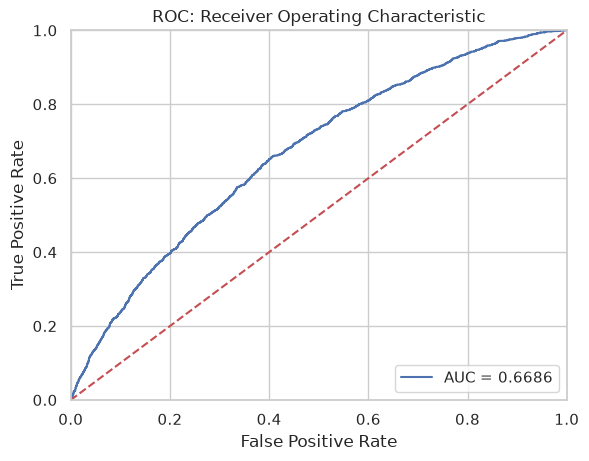

In [35]:
# ROC Curve
fpr_lr, tpr_lr, threshold_lr = roc_curve(
    y_valid,
    y_proba_valid
)
roc_auc_lr = auc(
    fpr_lr, 
    tpr_lr
)
plt.title(f"ROC: Receiver Operating Characteristic")
plt.plot(fpr_lr, tpr_lr, 'b', label = 'AUC = %0.4f' % roc_auc_lr)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel(f"True Positive Rate")
plt.xlabel(f"False Positive Rate")
plt.show()

In [36]:
df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_valid), columns=['y_actual']), pd.DataFrame(y_proba_valid, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_valid.index

df_actual_predicted = df_actual_predicted.sort_values('y_pred_proba')
df_actual_predicted = df_actual_predicted.reset_index()

df_actual_predicted['Cumulative N Population'] = df_actual_predicted.index + 1
df_actual_predicted['Cumulative N Bad'] = df_actual_predicted['y_actual'].cumsum()
df_actual_predicted['Cumulative N Good'] = df_actual_predicted['Cumulative N Population'] - df_actual_predicted['Cumulative N Bad']
df_actual_predicted['Cumulative Perc Population'] = df_actual_predicted['Cumulative N Population'] / df_actual_predicted.shape[0]
df_actual_predicted['Cumulative Perc Bad'] = df_actual_predicted['Cumulative N Bad'] / df_actual_predicted['y_actual'].sum()
df_actual_predicted['Cumulative Perc Good'] = df_actual_predicted['Cumulative N Good'] / (df_actual_predicted.shape[0] - df_actual_predicted['y_actual'].sum())

In [37]:
df_actual_predicted.head()

,member_id,y_actual,y_pred_proba,Cumulative N Population,Cumulative N Bad,Cumulative N Good,Cumulative Perc Population,Cumulative Perc Bad,Cumulative Perc Good
0,957991,0,0.021128,1,0,1,0.000094,0.0,0.000111
1,1210824,0,0.023188,2,0,2,0.000189,0.0,0.000223
2,1273525,0,0.023854,3,0,3,0.000283,0.0,0.000334
3,948614,0,0.024364,4,0,4,0.000378,0.0,0.000445
4,984044,0,0.024381,5,0,5,0.000472,0.0,0.000557


<br>

**LogReg - Test Set**:

In [38]:
print_report_and_cm(
    y_test, y_pred_test,
    f"Classification Report & Confusion Matrix | {f'Test Set'}"
)


Classification Report & Confusion Matrix | Test Set
              precision    recall  f1-score   support

    GOOD (0)       0.88      0.86      0.87     19346
     BAD (1)       0.24      0.27      0.25      3135

    accuracy                           0.78     22481
   macro avg       0.56      0.57      0.56     22481
weighted avg       0.79      0.78      0.79     22481



,Pred GOOD (0),Pred BAD (1)
Actual GOOD (0),16710,2636
Actual BAD (1),2300,835


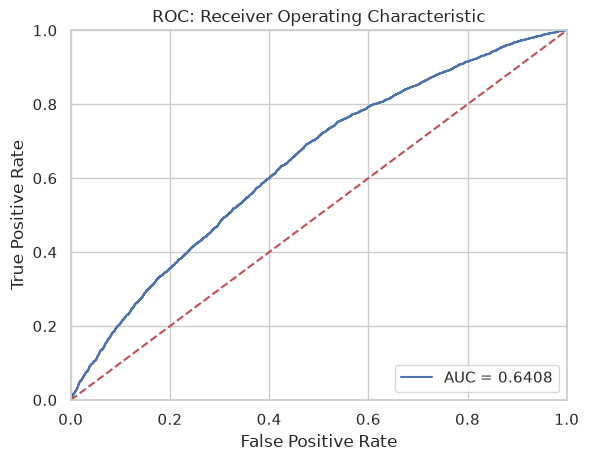

In [39]:
# ROC Curve
fpr_lr, tpr_lr, threshold_lr = roc_curve(
    y_test, 
    y_proba_test
)
roc_auc_lr = auc(
    fpr_lr, 
    tpr_lr
)
plt.title(f"ROC: Receiver Operating Characteristic")
plt.plot(fpr_lr, tpr_lr, 'b', label = 'AUC = %0.4f' % roc_auc_lr)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel(f"True Positive Rate")
plt.xlabel(f"False Positive Rate")
plt.show()

<br>

---
## **3.6. Probability Calibration:**

In [40]:
from src.helpers import (
    CALIBRATION_STRATEGIES, 
    extract_positive_proba, 
    run_probability_pipeline,
)

from src.calibration_selection import (
    evaluate_calibration_strategies,
    reliability_table,
    brier_skill_score
)

data_splits_logreg = {
    "train_cal": X_train_cal,   
    "valid":     X_valid_lr,   
    "test":      X_test_lr,
}

proba_store_lr = run_probability_pipeline(
    fitted_models={"logreg_scorecard": logreg},
    data_splits=data_splits_logreg,
    y_train_cal=y_train_cal,   
)

result = evaluate_calibration_strategies(
    proba_store_lr,
    y_by_split={"train_cal": y_train_cal, "valid": y_valid, "test": y_test},
    base_model_names=["logreg_scorecard"],
    decision_split="test",
)

display(result.winners)   # strategi mana yang menang + Brier/LogLoss-nya di OOT
display(result.table)     # breakdown lengkap semua strategi x semua split, untuk laporan
display(reliability_table(y_test, proba_store_lr["logreg_scorecard_cal_sigmoid"]["test"]))  # kurva kalibrasi

,model,winning_strategy,brier_test,logloss_test
0,logreg_scorecard,isotonic,0.117163,0.391418


,model,strategy,split,brier,logloss
0,logreg_scorecard,raw,train_cal,0.124293,0.408011
1,logreg_scorecard,raw,valid,0.123200,0.403519
2,logreg_scorecard,raw,test,0.117348,0.391276
3,logreg_scorecard,sigmoid,train_cal,0.124604,0.409584
4,logreg_scorecard,sigmoid,valid,0.123720,0.406121
5,logreg_scorecard,sigmoid,test,0.117595,0.392554
6,logreg_scorecard,isotonic,train_cal,0.123701,0.405633
7,logreg_scorecard,isotonic,valid,0.123230,0.404245
8,logreg_scorecard,isotonic,test,0.117163,0.391418


,decile,count,mean_predicted,observed_rate
0,"(0.0692, 0.0941]",2249,0.086808,0.050689
1,"(0.0941, 0.104]",2248,0.099227,0.079181
2,"(0.104, 0.113]",2248,0.108454,0.092082
3,"(0.113, 0.123]",2248,0.117854,0.092972
4,"(0.123, 0.134]",2248,0.128351,0.126779
5,"(0.134, 0.149]",2248,0.140963,0.158808
6,"(0.149, 0.167]",2248,0.157310,0.170819
7,"(0.167, 0.196]",2248,0.180384,0.159253
8,"(0.196, 0.249]",2248,0.219347,0.205961
9,"(0.249, 0.714]",2248,0.331088,0.258007


In [41]:
pd.DataFrame([{**brier_skill_score(y_train_cal, logreg.predict_proba(X_train_cal)[:, 1])}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.152352,0.124293,0.129141,0.037537


In [42]:
pd.DataFrame([{**brier_skill_score(y_valid, y_proba_valid)}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.152416,0.1232,0.129185,0.046334


In [43]:
pd.DataFrame([{**brier_skill_score(y_test, y_proba_test)}])

,base_rate,brier_model,brier_trivial,skill_score
0,0.139451,0.117348,0.120004,0.022136


In [44]:
print("Train bad rate :", y_train.mean().round(6))
print("Cal   bad rate :", y_train_cal.mean().round(6))
print("Valid bad rate :", y_valid.mean().round(6))
print("Test  bad rate :", y_test.mean().round(6))

Train bad rate : 0.152406
Cal   bad rate : 0.152352
Valid bad rate : 0.152416
Test  bad rate : 0.139451


<br>

---
## **3.7. Kolmogorov-Smirnov (KS) Statistics**:

=== KS STATISTICS (WINNER MODEL: FINAL THRESHOLD ALIGNMENT) ===


,Dataset,KS Statistic,KS (%),KS Threshold,Interpretasi
0,Training (train_fit),0.2440,24.40,0.1471,adequate
1,Validation,0.2524,25.24,0.1466,adequate
2,Test,0.2165,21.65,0.1402,adequate


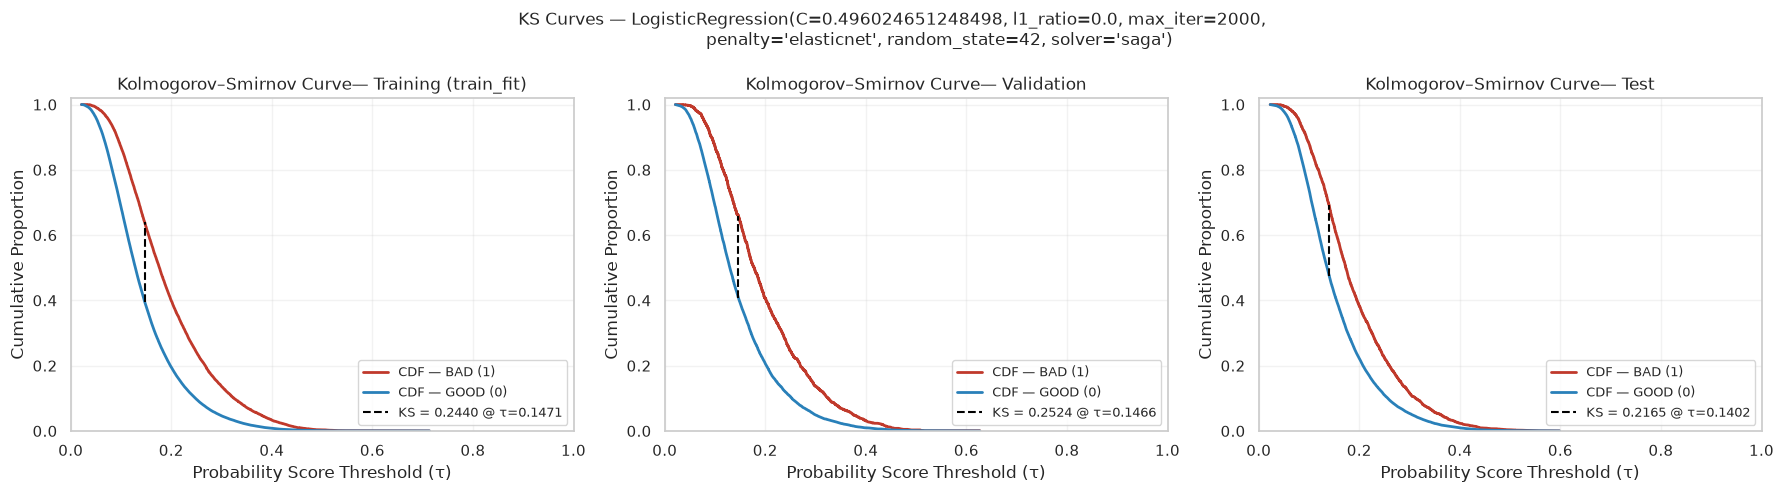

In [45]:
"""
Implementation of Kolmogorov-Smirnov (KS) Statistics as a Complementary Diagnostic
for the Evaluation of Binary Credit Risk Classification Models.

Theoretical context:
    KS = max_tau | F_BAD(tau) - F_GOOD(tau) |
       = max_tau | TPR(tau) - FPR(tau) |

Mathematically KS is identical to the maximum value of the Youden index (KS = max J),
but is reported as a single scalar that summarizes the overall separation capacity of the model,
accompanied by a visualization of two cumulative CDF curves of the prediction scores for each class (GOOD vs BAD).

Industry interpretation convention (Siddiqi, 2017, Credit Risk Scorecards):
    KS < 20%   : Weak discrimination
    20% - 40%  : Adequate discrimination
    > 40%      : Strong discrimination
"""

if __name__ == "__main__":
    
    datasets = {
        'Training (train_fit)' : (y_train, y_proba_train),
        'Validation'           : (y_valid, y_proba_valid),
        'Test'                 : (y_test,  y_proba_test),
    }
    print(f"=== KS STATISTICS (WINNER MODEL: FINAL THRESHOLD ALIGNMENT) ===")
    from src.ks_statistic_evaluation import ks_report_table, plot_ks_curve
    ks_table = ks_report_table(datasets)
    display(ks_table)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, (y_t, p)) in zip(axes, datasets.items()):
        plot_ks_curve(y_t, p, dataset_name=name, ax=ax)
    plt.suptitle(f"KS Curves — {logreg}", fontsize=12)
    plt.tight_layout()
    plt.savefig("ks_curves_all_partitions_LR.png", dpi=150)
    plt.show()
    pass

<br>

---
## **3.8. Expected Cost Function**:

===== Estimasi Komponen Biaya =====
C_FN (kerugian default) : 8250000.0000
C_FP (opportunity cost) : 2700000.0000
Rasio C_FN/C_FP         : 3.0556
Tau optimal-biaya       : 0.2352
Recall BAD di tau optimal-biaya : 0.2972

===== Perbandingan Ambang Threshold =====
Tau optimal-biaya : 0.2352
Tau Youden's J    : 0.1466
Tau F1 maksimal   : 0.1472
Rasio C_FN/C_FP   : 3.0600
Interpretasi: Dengan rasio C_FN/C_FP = 3.0556, ambang optimal-biaya berada di atas ambang Youden -- selisih 0.0886 pada skala probabilitas.


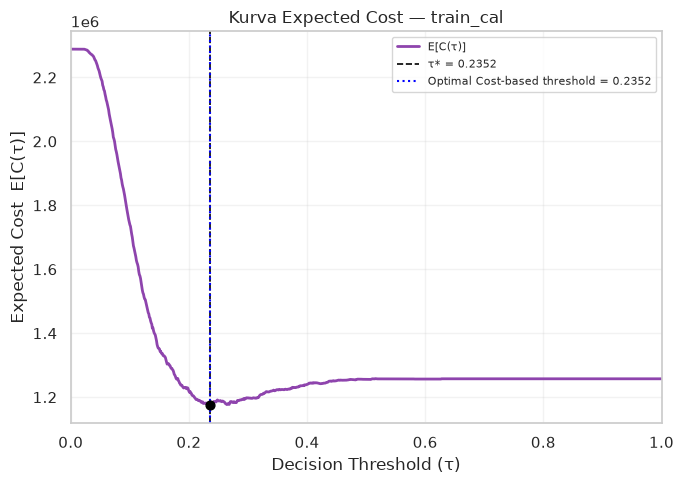

In [46]:
"""
Implementasi Fungsi Expected Cost untuk Penentuan Ambang Keputusan Optimal-Biaya
pada Model Klasifikasi Risiko Kredit Biner.

Kerangka teoretis (Elkan, 2001; BCBS, 2006 untuk estimasi komponen LGD/EAD):

    E[C(tau)] = C_FN * P(y=1) * P(yhat=0 | y=1, tau)
              + C_FP * P(y=0) * P(yhat=1 | y=0, tau)

    di mana:
        P(yhat=0 | y=1, tau) = 1 - Recall_BAD(tau)      [False Negative Rate]
        P(yhat=1 | y=0, tau) = FPR(tau)                  [False Positive Rate]

    C_FN (biaya false negative, memberi pinjaman pada peminjam yang gagal bayar)
        didekomposisi sebagai:  C_FN ≈ EAD * LGD

    C_FP (biaya false positive, menolak peminjam yang sesungguhnya baik)
        didekomposisi sebagai opportunity cost margin bunga marjinal:
        C_FP ≈ EAD * spread_bunga * durasi_pinjaman

    tau* = argmin_tau E[C(tau)]

Catatan epistemik penting:
    C_FN dan C_FP di sini adalah ESTIMASI PORTOFOLIO-LEVEL, bukan kepastian
    per-individu. Modul ini menyediakan dua mode: (a) biaya skalar tetap
    (rasio C_FN/C_FP konstan di seluruh observasi), dan (b) biaya per-observasi
    bila EAD bervariasi antar peminjam (mis. plafon pinjaman berbeda) --
    mode (b) lebih realistis untuk portofolio kredit konsumen heterogen.
"""

if __name__ == "__main__":
    # --- Scalar mode: portfolio mean estimate ---
    # Misal: EAD rata-rata Rp 15.000.000, LGD historis 55%,
    # For example: Average EAD Rp. 15,000,000, historical LGD 55%,
    # interest spread 9%/year, average loan duration 2 years.
    from src.expected_cost_threshold import (
    estimate_cost_components, expected_cost_curve_scalar, 
    compare_threshold_criteria, plot_expected_cost_curve)
    
    components = estimate_cost_components(
        ead=15_000_000,
        lgd=0.55,
        interest_spread=0.09,
        loan_duration_years=2.0,
    )
    def print_cost_report(components):
        print(f"===== Estimasi Komponen Biaya =====")
        print(f"C_FN (kerugian default) : {components['C_FN']:.4f}")
        print(f"C_FP (opportunity cost) : {components['C_FP']:.4f}")
        print(f"Rasio C_FN/C_FP         : {components['ratio_CFN_CFP']:.4f}")

    print_cost_report(components)
    # C_FN = 15jt * 0.55 = 8.25jt
    # C_FP = 15jt * 0.09 * 2 = 2.7jt
    # rasio C_FN/C_FP ≈ 3.06
    
    cost_result = expected_cost_curve_scalar(
        y_valid, y_proba_valid,
        c_fn=components['C_FN'], c_fp=components['C_FP']
    )
    print(f"Tau optimal-biaya       : {cost_result['optimal_threshold']:.4f}")
    print(f"Recall BAD di tau optimal-biaya : {cost_result['optimal_recall_bad']:.4f}\n")
    
    comparison = compare_threshold_criteria(
        y_valid, y_proba_valid, components['C_FN'], components['C_FP']
    )
    print(f"===== Perbandingan Ambang Threshold =====")
    print(f"Tau optimal-biaya : {comparison['tau_expected_cost']:.4f}")
    print(f"Tau Youden's J    : {comparison['tau_youden_j']:.4f}")
    print(f"Tau F1 maksimal   : {comparison['tau_f1_maximal']:.4f}")
    print(f"Rasio C_FN/C_FP   : {comparison['cost_ratio_CFN_CFP']:.4f}")
    print(f"Interpretasi: {comparison['interpretasi']}")
    
    ax_cost = plot_expected_cost_curve(cost_result, dataset_name='train_cal')

    ax_cost.axvline(
        optimal_cost_threshold,
        color='blue', linestyle=':', linewidth=1.5,
        label=f"Optimal Cost-based threshold = {optimal_cost_threshold:.4f}"
    )
    ax_cost.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("expected_cost_curve_valid_LR.png", dpi=150)
    plt.show()
    pass

<br>

---
## **3.9. Credit Scorecard**:

In [47]:
# Coefficient
logreg.coef_

array([[-0.84917297, -0.43368322, -0.19047641, -1.00771301, -1.29351633,
        -0.47764228, -1.17962966, -0.56511535, -1.1098669 , -0.8932072 ,
        -1.04060637, -0.91302069]])

In [48]:
# Intercept
logreg.intercept_

array([-1.71922162])

=== TOP 5 HIGH RISK INDICATORS (Lower Score) ===
Empty DataFrame
Columns: [Characteristics, Coefficient, Point]
Index: []

=== TOP 5 LOW RISK INDICATORS (Increasing Score) ===
       Characteristics  Coefficient  Point
    has_derogatory_woe    -1.293516     37
    inq_last_6mths_woe    -1.179630     34
    open_acc_ratio_woe    -1.109867     32
        revol_util_woe    -1.040606     30
emp_length_ordinal_woe    -1.007713     29


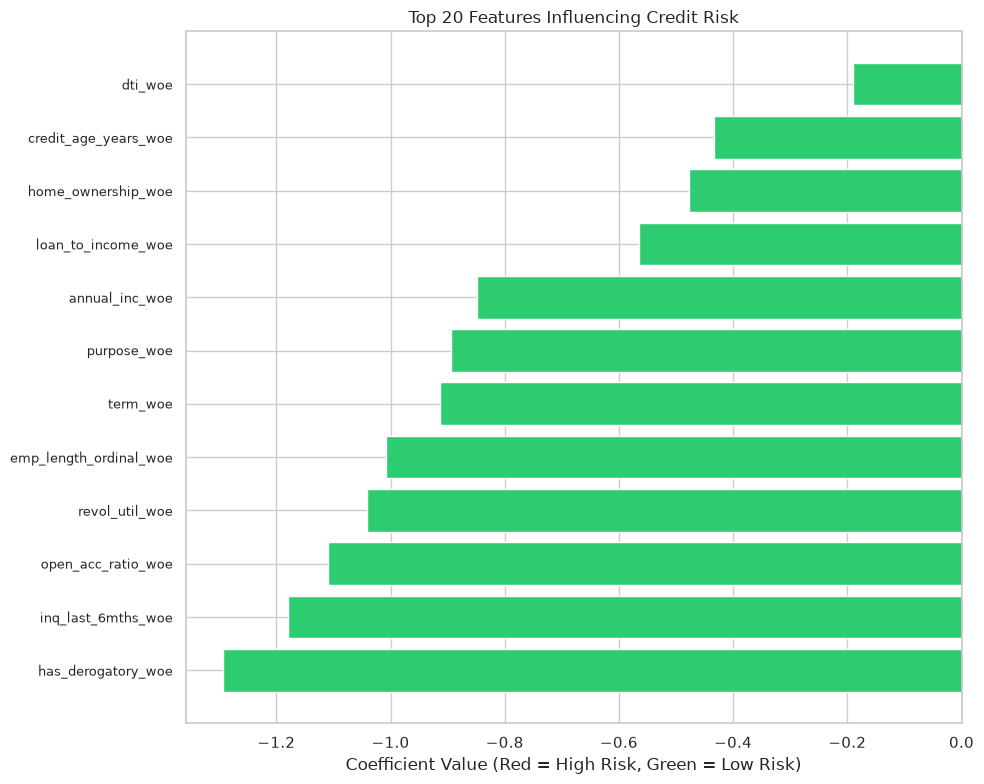

,Characteristics,Coefficient,Point
0,Base Score (Intercept),-1.719222,537
1,has_derogatory_woe,-1.293516,37
2,inq_last_6mths_woe,-1.179630,34
3,open_acc_ratio_woe,-1.109867,32
4,revol_util_woe,-1.040606,30
5,emp_length_ordinal_woe,-1.007713,29
6,term_woe,-0.913021,26
7,purpose_woe,-0.893207,26
8,annual_inc_woe,-0.849173,25
9,loan_to_income_woe,-0.565115,16



=== AUTOMATIC WRONG-SIGN COEFFICIENT DETECTION ===


,Feature,Coefficient,Expected Sign,Status
0,annual_inc_woe,-0.849173,Negative (< 0),OK
1,credit_age_years_woe,-0.433683,Negative (< 0),OK
2,dti_woe,-0.190476,Negative (< 0),OK
3,emp_length_ordinal_woe,-1.007713,Negative (< 0),OK
4,has_derogatory_woe,-1.293516,Negative (< 0),OK
5,home_ownership_woe,-0.477642,Negative (< 0),OK
6,inq_last_6mths_woe,-1.179630,Negative (< 0),OK
7,loan_to_income_woe,-0.565115,Negative (< 0),OK
8,open_acc_ratio_woe,-1.109867,Negative (< 0),OK
9,purpose_woe,-0.893207,Negative (< 0),OK



Suggested features to drop: []


In [49]:
def build_comprehensive_scorecard(model, feature_names, target_score=600, target_odds=50, pdo=20):
    """
    Functions for evaluating coefficients and building Credit Scorecards.
    """
    # =======================================================
    # PART 1: SCORECARD PARAMETERS CALCULATION
    # =======================================================
    # Scorecard calibration standard formula:
    factor = pdo / np.log(2)
    offset = target_score - (factor * np.log(target_odds))
    
    intercept = model.intercept_[0]
    coefs = model.coef_[0]
    
    # Since the model predicts BAD (default), a positive probability value indicates high risk.
    # To make a high scorecard score mean "Safe/Good," we assign a negative sign to the coefficient.
    base_score = offset - (intercept * factor)
    
    # =======================================================
    # PART 2: TABLE CREATION AND POINT CALCULATION
    # =======================================================
    # Combine features and coefficients into a DataFrame
    df_scorecard = pd.DataFrame({
        'Characteristics': feature_names,
        'Coefficient': coefs
    })
    
    # Count points and round to integer (banking standard)
    df_scorecard['Point'] = -(df_scorecard['Coefficient'] * factor)
    df_scorecard['Point'] = df_scorecard['Point'].round().astype(int)
    
    # Separate for coefficient analysis
    df_scorecard['Abs_Coefficient'] = df_scorecard['Coefficient'].abs()
    df_scorecard_sorted = df_scorecard.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])
    
    # Prepare the Base Score row to be placed at the top
    base_row = pd.DataFrame({
        'Characteristics': ['Base Score (Intercept)'],
        'Coefficient': [intercept],
        'Point': [round(base_score)]
    })
    
    # Merge into final table
    final_scorecard_table = pd.concat([base_row, df_scorecard_sorted], ignore_index=True)
    
    # =======================================================
    # PART 3: VISUALIZATION & PRINT RESULTS
    # =======================================================
    print(f"=== TOP 5 HIGH RISK INDICATORS (Lower Score) ===")
    top_pos = df_scorecard[df_scorecard['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(5)
    print(top_pos[['Characteristics', 'Coefficient', 'Point']].to_string(index=False))
    
    print(f"\n=== TOP 5 LOW RISK INDICATORS (Increasing Score) ===")
    top_neg = df_scorecard[df_scorecard['Coefficient'] < 0].sort_values(by='Coefficient', ascending=True).head(5)
    print(top_neg[['Characteristics', 'Coefficient', 'Point']].to_string(index=False))
    
    # Coefficient Visualization (Using top 20 features to keep the graph from being too crowded)
    top_n_features = df_scorecard.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    # Reorder the graph of coefficient values to show the contrast between positive and negative risks.
    top_n_features = top_n_features.sort_values(by='Coefficient', ascending=True) 
    
    colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_n_features['Coefficient']]
    plt.barh(top_n_features['Characteristics'], top_n_features['Coefficient'], color=colors)
    
    plt.xlabel('Coefficient Value (Red = High Risk, Green = Low Risk)')
    plt.title('Top 20 Features Influencing Credit Risk')
    plt.axvline(x=0, color='black', linewidth=1) # Center line boundary 0
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()
    # To view the entire table:
    pd.set_option('display.max_rows', None)
    display(final_scorecard_table.sort_values(by='Coefficient', ascending=True))

    # Merge into Dictionary
    model_coefficients = dict(zip(feature_names, coefs))
    
    # Perform automatic detection
    wrong_sign_results = []
    for feature, coef in model_coefficients.items():
        # Target standard assumptions: 1 = BAD, positive WoE = GOOD
        if feature.endswith('_woe'):
            is_wrong = coef > 0
            expected = "Negative (< 0)"
        else:
            # If there are non-WoE features (e.g. native binary, 1 = has bad history)
            is_wrong = coef < 0
            expected = "Positive (> 0)"
        
        wrong_sign_results.append({
            'Feature': feature,
            'Coefficient': coef,
            'Expected Sign': expected,
            'Status': 'WRONG SIGN!' if is_wrong else 'OK'
        })

    wrong_sign_df = pd.DataFrame(wrong_sign_results)
    print(f"\n=== AUTOMATIC WRONG-SIGN COEFFICIENT DETECTION ===")
    display(wrong_sign_df)

    # Filter only the wrong direction to drop
    features_to_drop = wrong_sign_df[wrong_sign_df['Status'] == 'WRONG SIGN!']['Feature'].tolist()
    print(f"\nSuggested features to drop:", features_to_drop)


# --- RUN ---
FEATURES = X_train_lr.columns.tolist()
build_comprehensive_scorecard(
    model=logreg, 
    feature_names=FEATURES, 
    target_score=600, 
    target_odds=50, 
    pdo=20
)

In [50]:
# X set:
X_valid_raw = deserialize_data('data/interim/X_valid_raw.pkl')
X_test_raw  = deserialize_data('data/interim/X_test_raw.pkl')

Data successfully deserialized from data/interim/X_valid_raw.pkl
Data successfully deserialized from data/interim/X_test_raw.pkl


In [51]:
from src.scorecard import (
    ScorecardConfig,
    build_scorecard,
    audit_scorecard,
    explain_score, 
    export_scorecard_report, 
    score_dataframe,
    validate_scorecard_consistency
)

config = ScorecardConfig(
    target_score=600,
    target_odds=50,
    pdo=20,
)

# Load the binning_artifacts object from the `.pkl` file
binning_artifacts_loaded = joblib.load('./binning_artifacts.pkl')
# If using pickle:
# with open('./binning_artifacts.pkl', 'rb') as f:
#     binning_artifacts_loaded = pickle.load(f)

scorecard = build_scorecard(
    model=logreg,
    binning_artifacts=binning_artifacts_loaded,
    feature_names=FEATURES,
    config=config,
)
scorecard.lookup_table

(CVXPY) Jul 19 03:47:11 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/home/gontommuhammad/miniconda3/envs/credit-risk_VENV/lib/python3.13/site-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


,characteristic,bin_label,count,woe,coefficient,point
0,annual_inc,less_28572,6316,-0.243057,-0.849173,-6
1,annual_inc,28572_to_36836,8415,-0.212624,-0.849173,-5
2,annual_inc,36836_to_43986.74,8348,-0.180251,-0.849173,-4
3,annual_inc,43986.74_to_60606,21866,-0.077428,-0.849173,-2
4,annual_inc,60606_to_66096,5441,0.036320,-0.849173,1
5,annual_inc,66096_to_75328.5,8273,0.078679,-0.849173,2
6,annual_inc,75328.5_to_82718,4555,0.120887,-0.849173,3
7,annual_inc,82718_to_92124,5447,0.151563,-0.849173,4
8,annual_inc,92124_to_129449.5,10219,0.328782,-0.849173,8
9,annual_inc,greater_129449.5,5884,0.346067,-0.849173,8


In [52]:
scores = score_dataframe(
    scorecard,
    X_valid_raw
)

scores.head()

member_id
1881671    540
1290221    504
610428     543
178070     531
1045161    526
dtype: int64

In [53]:
diagnostics = validate_scorecard_consistency(
    scorecard,
    X_valid_raw
)

diagnostics

{'mean_abs_diff': 0.653688193185533,
 'max_abs_diff': 3.060724491202791,
 'n_flagged': 0,
 'n_total': 10596,
 'tolerance': 6.5}

In [54]:
explain_score(
    scorecard,
    X_valid_raw.iloc[[2]]
)

,characteristic,bin_label,point
0,Base Score,-,537
1,term,36_months,5
2,revol_util,65.95_to_75.45,-4
3,open_acc_ratio,0.3_to_0.41,3
4,loan_to_income,0.16_to_0.19,3
5,inq_last_6mths,0.5_to_1.5,-2
6,purpose,debt_consolidation,-2
7,annual_inc,66096_to_75328.5,2
8,credit_age_years,greater_17.46,1
9,emp_length_ordinal,greater_5.5,-1


In [55]:
audit_scorecard(scorecard)

,section,check,status,n_issues,details
0,Lookup,duplicate characteristic + bin_label,PASS,0,[]
1,Lookup,missing point,PASS,0,
2,Lookup,missing woe,PASS,0,
3,Lookup,missing coefficient,PASS,0,
4,Mapping,no empty characteristic,PASS,0,
5,Mapping,all characteristics have at least one bin,PASS,0,missing=[]
6,Point,point type is integer,PASS,0,
7,Point,point is finite and non-null,PASS,0,
8,WoE,woe type is float,PASS,0,
9,WoE,woe is finite and non-null,PASS,0,


```python
print(export_scorecard_report(scorecard))
```
## **Credit Scorecard**

---

### **Scaling**

- Target score: **600** at odds **50:1**
- PDO (Points to Double the Odds): **20**

---

### **Base Score**

| Component | Point |
|---|---:|
| Intercept + offset | 537 |

---
### **Characteristic Points**

| Characteristic | Bin | Point | Count | WoE | Coefficient |
| --- | --- | ---: | ---: | ---: | ---: |
| annual_inc | less_28572 | -6 | 6316 | -0.2431 | -0.8492 |
| annual_inc | 28572_to_36836 | -5 | 8415 | -0.2126 | -0.8492 |
| annual_inc | 36836_to_43986.74 | -4 | 8348 | -0.1803 | -0.8492 |
| annual_inc | 43986.74_to_60606 | -2 | 21866 | -0.0774 | -0.8492 |
| annual_inc | 60606_to_66096 | 1 | 5441 | 0.0363 | -0.8492 |
| annual_inc | 66096_to_75328.5 | 2 | 8273 | 0.0787 | -0.8492 |
| annual_inc | 75328.5_to_82718 | 3 | 4555 | 0.1209 | -0.8492 |
| annual_inc | 82718_to_92124 | 4 | 5447 | 0.1516 | -0.8492 |
| annual_inc | 92124_to_129449.5 | 8 | 10219 | 0.3288 | -0.8492 |
| annual_inc | greater_129449.5 | 8 | 5884 | 0.3461 | -0.8492 |
| annual_inc | Special | 0 | 0 | 0.0000 | -0.8492 |
| annual_inc | Missing | 0 | 0 | 0.0000 | -0.8492 |
| credit_age_years | less_7.88 | -1 | 13867 | -0.0818 | -0.4337 |
| credit_age_years | 7.88_to_14.79 | 0 | 38105 | -0.0337 | -0.4337 |
| credit_age_years | 14.79_to_17.46 | 0 | 11083 | 0.0361 | -0.4337 |
| credit_age_years | greater_17.46 | 1 | 21709 | 0.0987 | -0.4337 |
| credit_age_years | Special | 0 | 0 | 0.0000 | -0.4337 |
| credit_age_years | Missing | 0 | 0 | 0.0000 | -0.4337 |
| dti | less_5.95 | 1 | 9867 | 0.2613 | -0.1905 |
| dti | 5.95_to_7.79 | 1 | 5066 | 0.2269 | -0.1905 |
| dti | 7.79_to_9.19 | 1 | 4612 | 0.1353 | -0.1905 |
| dti | 9.19_to_12.23 | 1 | 11133 | 0.1209 | -0.1905 |
| dti | 12.23_to_13.82 | 0 | 6364 | 0.0557 | -0.1905 |
| dti | 13.82_to_16.03 | 0 | 9086 | 0.0456 | -0.1905 |
| dti | 16.03_to_17.95 | 0 | 7647 | -0.0307 | -0.1905 |
| dti | 17.95_to_20.16 | -1 | 8383 | -0.1020 | -0.1905 |
| dti | 20.16_to_21.91 | -1 | 6004 | -0.1633 | -0.1905 |
| dti | 21.91_to_27.38 | -1 | 11920 | -0.1849 | -0.1905 |
| dti | greater_27.38 | -2 | 4682 | -0.2981 | -0.1905 |
| dti | Special | 0 | 0 | 0.0000 | -0.1905 |
| dti | Missing | 0 | 0 | 0.0000 | -0.1905 |
| emp_length_ordinal | less_3.5 | 2 | 30281 | 0.0555 | -1.0077 |
| emp_length_ordinal | 3.5_to_5.5 | 1 | 13827 | 0.0370 | -1.0077 |
| emp_length_ordinal | greater_5.5 | -1 | 37984 | -0.0295 | -1.0077 |
| emp_length_ordinal | Special | 0 | 0 | 0.0000 | -1.0077 |
| emp_length_ordinal | Missing | -10 | 2672 | -0.3403 | -1.0077 |
| inq_last_6mths | less_0.5 | 7 | 40651 | 0.2151 | -1.1796 |
| inq_last_6mths | 0.5_to_1.5 | -2 | 23255 | -0.0577 | -1.1796 |
| inq_last_6mths | 1.5_to_2.5 | -6 | 12117 | -0.1838 | -1.1796 |
| inq_last_6mths | greater_2.5 | -15 | 8741 | -0.4321 | -1.1796 |
| inq_last_6mths | Special | 0 | 0 | 0.0000 | -1.1796 |
| inq_last_6mths | Missing | 0 | 0 | 0.0000 | -1.1796 |
| loan_to_income | less_0.06 | 6 | 7421 | 0.3643 | -0.5651 |
| loan_to_income | 0.06_to_0.1 | 5 | 9483 | 0.3243 | -0.5651 |
| loan_to_income | 0.1_to_0.13 | 4 | 8801 | 0.2511 | -0.5651 |
| loan_to_income | 0.13_to_0.16 | 4 | 8530 | 0.2324 | -0.5651 |
| loan_to_income | 0.16_to_0.19 | 3 | 8789 | 0.1696 | -0.5651 |
| loan_to_income | 0.19_to_0.23 | 1 | 11537 | 0.0431 | -0.5651 |
| loan_to_income | 0.23_to_0.26 | 0 | 6368 | 0.0067 | -0.5651 |
| loan_to_income | 0.26_to_0.29 | -3 | 4563 | -0.2005 | -0.5651 |
| loan_to_income | 0.29_to_0.32 | -4 | 4866 | -0.2355 | -0.5651 |
| loan_to_income | 0.32_to_0.37 | -6 | 6225 | -0.3752 | -0.5651 |
| loan_to_income | greater_0.37 | -10 | 8181 | -0.6047 | -0.5651 |
| loan_to_income | Special | 0 | 0 | 0.0000 | -0.5651 |
| loan_to_income | Missing | 0 | 0 | 0.0000 | -0.5651 |
| open_acc_ratio | less_0.3 | 4 | 13053 | 0.1176 | -1.1099 |
| open_acc_ratio | 0.3_to_0.41 | 3 | 20353 | 0.0922 | -1.1099 |
| open_acc_ratio | 0.41_to_0.47 | 1 | 11401 | 0.0174 | -1.1099 |
| open_acc_ratio | 0.47_to_0.58 | -1 | 16872 | -0.0334 | -1.1099 |
| open_acc_ratio | 0.58_to_0.65 | -2 | 7515 | -0.0642 | -1.1099 |
| open_acc_ratio | 0.65_to_0.78 | -4 | 9621 | -0.1254 | -1.1099 |
| open_acc_ratio | greater_0.78 | -6 | 5949 | -0.1837 | -1.1099 |
| open_acc_ratio | Special | 0 | 0 | 0.0000 | -1.1099 |
| open_acc_ratio | Missing | 0 | 0 | 0.0000 | -1.1099 |
| revol_util | less_16.85 | 14 | 9726 | 0.4549 | -1.0406 |
| revol_util | 16.85_to_27.35 | 11 | 6516 | 0.3792 | -1.0406 |
| revol_util | 27.35_to_38.55 | 6 | 8507 | 0.2133 | -1.0406 |
| revol_util | 38.55_to_47.55 | 3 | 8145 | 0.1017 | -1.0406 |
| revol_util | 47.55_to_55.05 | 1 | 7604 | 0.0255 | -1.0406 |
| revol_util | 55.05_to_65.95 | -1 | 12190 | -0.0446 | -1.0406 |
| revol_util | 65.95_to_75.45 | -4 | 10505 | -0.1431 | -1.0406 |
| revol_util | 75.45_to_80.55 | -5 | 5594 | -0.1542 | -1.0406 |
| revol_util | 80.55_to_85.75 | -7 | 5447 | -0.2273 | -1.0406 |
| revol_util | 85.75_to_92.65 | -9 | 6075 | -0.2911 | -1.0406 |
| revol_util | greater_92.65 | -13 | 4455 | -0.4396 | -1.0406 |
| revol_util | Special | 0 | 0 | 0.0000 | -1.0406 |
| revol_util | Missing | 0 | 0 | 0.0000 | -1.0406 |
| has_derogatory | No_Derogatory | 1 | 71100 | 0.0358 | -1.2935 |
| has_derogatory | Has_Derogatory | -6 | 13664 | -0.1733 | -1.2935 |
| has_derogatory | Special | 0 | 0 | 0.0000 | -1.2935 |
| has_derogatory | Missing | 0 | 0 | 0.0000 | -1.2935 |
| home_ownership | MORTGAGE | 1 | 38847 | 0.0789 | -0.4776 |
| home_ownership | OWN | -1 | 6590 | -0.0425 | -0.4776 |
| home_ownership | OTHER_RENT | -1 | 39327 | -0.0670 | -0.4776 |
| home_ownership | Special | 0 | 0 | 0.0000 | -0.4776 |
| home_ownership | Missing | 0 | 0 | 0.0000 | -0.4776 |
| purpose | car_major_purchase | 11 | 5489 | 0.4160 | -0.8932 |
| purpose | credit_card | 7 | 14034 | 0.2746 | -0.8932 |
| purpose | home_improvement | 6 | 5377 | 0.2319 | -0.8932 |
| purpose | debt_consolidation | -2 | 44761 | -0.0648 | -0.8932 |
| purpose | other_small_business | -8 | 10170 | -0.3222 | -0.8932 |
| purpose | educational_house_medical_moving_renewable_energy_wedding | 0 | 4933 | 0.0012 | -0.8932 |
| purpose | Special | 0 | 0 | 0.0000 | -0.8932 |
| purpose | Missing | 0 | 0 | 0.0000 | -0.8932 |
| term | 36_months | 5 | 66404 | 0.1903 | -0.9130 |
| term | 60_months | -14 | 18360 | -0.5388 | -0.9130 |
| term | Special | 0 | 0 | 0.0000 | -0.9130 |
| term | Missing | 0 | 0 | 0.0000 | -0.9130 |

In [56]:
from src.helpers import save_best_model

# Save the Best Model to Disk
MODEL_SAVE_PATH = f"./models/LogisticRegression1.joblib"
save_best_model(logreg, MODEL_SAVE_PATH)

<br>

---
## **3.10. PCA 2D Visualization** <br>
* Blue = GOOD (0)
* Red  = BAD  (1)

In [57]:
from sklearn.decomposition import PCA

In [58]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

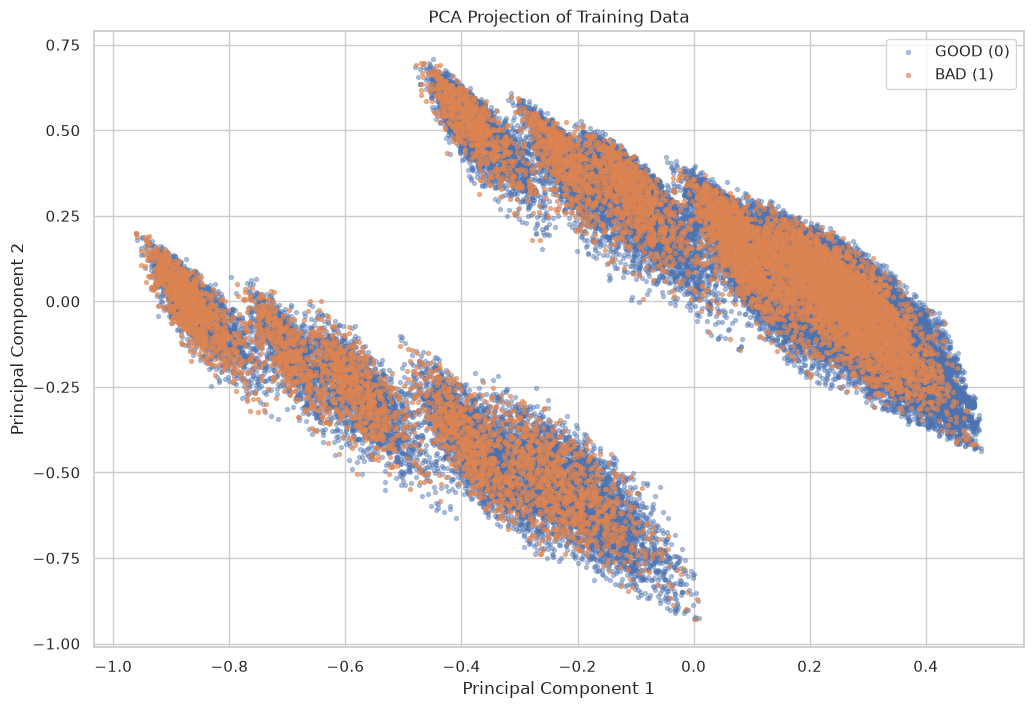

In [59]:
X_pca = pca.fit_transform(
    X_train_lr
)
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target': y_train.values
})

plt.figure(figsize=(12, 8))

good = plot_df['target'] == 0
bad = plot_df['target'] == 1

plt.scatter(
    plot_df.loc[good, 'PC1'],
    plot_df.loc[good, 'PC2'],
    s=8,
    alpha=0.4,
    label='GOOD (0)',
)

plt.scatter(
    plot_df.loc[bad, 'PC1'],
    plot_df.loc[bad, 'PC2'],
    s=8,
    alpha=0.6,
    label='BAD (1)',
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Training Data')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
from imblearn.over_sampling import BorderlineSMOTE
# Initialize the algorithm
bl_smote = BorderlineSMOTE(
    sampling_strategy=1.0,
    random_state=RANDOM_STATE
)
# Resample train set
X_train_blsmote, y_train_blsmote = bl_smote.fit_resample(
    X_train_lr, y_train
)
print(F"BEFORE BorderlineSMOTE:")
print(y_train.value_counts())

print(F"\nAFTER BorderlineSMOTE:")
print(y_train_blsmote.value_counts())

BEFORE BorderlineSMOTE:
target
0    63862
1    11483
Name: count, dtype: int64

AFTER BorderlineSMOTE:
target
0    63862
1    63862
Name: count, dtype: int64


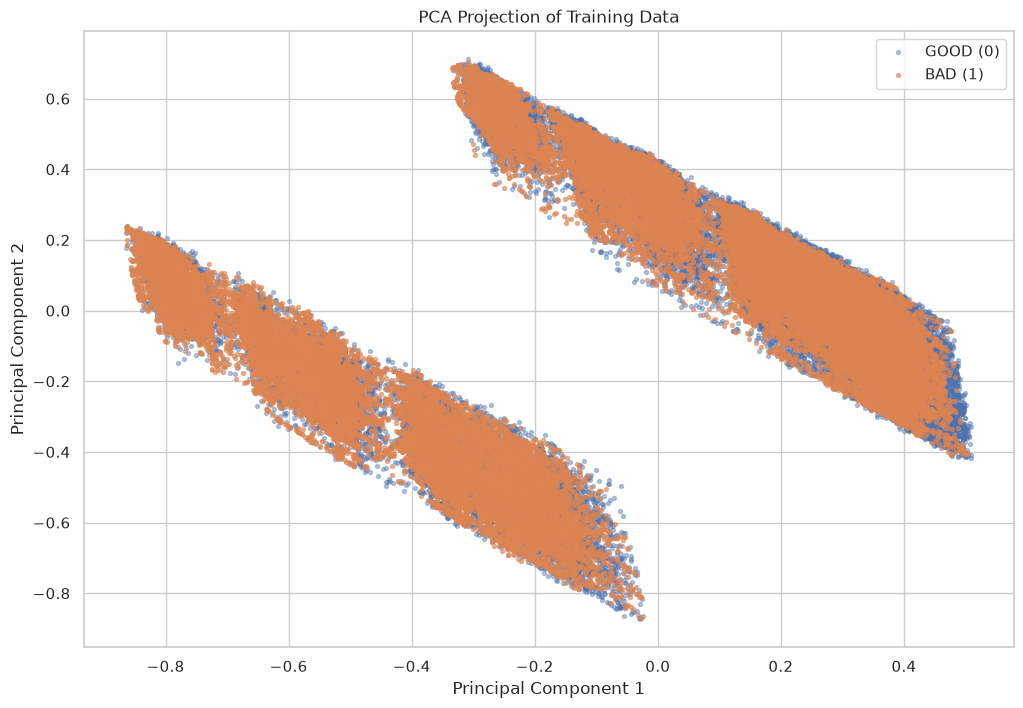

In [61]:
X_pca = pca.fit_transform(
    X_train_blsmote
)
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target': y_train_blsmote.values
})

plt.figure(figsize=(12, 8))

good = plot_df['target'] == 0
bad = plot_df['target'] == 1

plt.scatter(
    plot_df.loc[good, 'PC1'],
    plot_df.loc[good, 'PC2'],
    s=8,
    alpha=0.4,
    label='GOOD (0)',
)

plt.scatter(
    plot_df.loc[bad, 'PC1'],
    plot_df.loc[bad, 'PC2'],
    s=8,
    alpha=0.6,
    label='BAD (1)',
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Training Data')
plt.legend()
plt.grid(True)
plt.show()

<br>

---
## **3.11. LogReg + BorderlineSMOTE**:

In [62]:
# Refit Logistic Regression
logreg_blsmote = LogisticRegression(
    C=0.38461013019343815,
    class_weight=None,
    l1_ratio=0.4754992118174114,
    max_iter=2000,
    penalty='elasticnet',
    random_state=RANDOM_STATE,
    solver='saga'
)
logreg_blsmote.fit(X_train_blsmote, y_train_blsmote)

LogisticRegression(C=0.38461013019343815, l1_ratio=0.4754992118174114,
                   max_iter=2000, penalty='elasticnet', random_state=42,
                   solver='saga')

<br>

**Evaluate & Predict:**

In [63]:
train_metrics_blsmote, y_pred_train_blsmote, y_proba_train_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_train_lr, y=y_train, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Training',
    threshold=optimal_cost_threshold
)

valid_metrics_blsmote, y_pred_valid_blsmote, y_proba_valid_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_valid_lr, y=y_valid, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Validation',
    threshold=optimal_cost_threshold
)

test_metrics_blsmote, y_pred_test_blsmote, y_proba_test_blsmote = evaluate_model(
    model=logreg_blsmote, 
    X=X_test_lr, y=y_test, 
    model_name='LogReg + BorderlineSMOTE', 
    split_set='Test',
    threshold=optimal_cost_threshold
)

results = pd.concat([
    train_metrics_blsmote, 
    valid_metrics_blsmote, 
    test_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

ROC-AUC    PR-AUC   LogLoss  \
Model                    Split                                      
LogReg + BorderlineSMOTE Training    0.669218  0.262008  0.637966   
                         Validation  0.668588  0.255581  0.644811   
                         Test        0.642291  0.213524  0.669343   

                                     Brier Score      Gini  KS_Statistic  \
Model                    Split                                             
LogReg + BorderlineSMOTE Training       0.223420  0.338436      0.243633   
                         Validation     0.226474  0.337177      0.248393   
                         Test           0.237328  0.284581      0.219945   

                                     Balanced_Accuracy       MCC  \
Model                    Split                                     
LogReg + BorderlineSMOTE Training             0.542837  0.100515   
                         Validation           0.545064  0.106851   
                         Test                 0.528323  0.076211   

                                     Precision_Bad  Recall_Bad    F1_Bad  \
Model                    Split                                             
LogReg + BorderlineSMOTE Training         0.164769    0.967778  0.281595   
                         Validation       0.165387    0.973994  0.282761   
                         Test             0.146771    0.977352  0.255216   

                                     Specificity       NPV       FPR  \
Model                    Split                                         
LogReg + BorderlineSMOTE Training       0.117895  0.953159  0.882105   
                         Validation     0.116134  0.961290  0.883866   
                         Test           0.079293  0.955763  0.920707   

                                          FNR  Predicted_Bad_Rate    TN  \
Model                    Split                                            
LogReg + BorderlineSMOTE Training    0.032222            0.895162  7529   
                         Validation  0.026006            0.897603  1043   
                         Test        0.022648            0.928606  1534   

                                        FP   FN     TP  
Model                    Split                          
LogReg + BorderlineSMOTE Training    56333  370  11113  
                         Validation   7938   42   1573  
                         Test        17812   71   3064

<br>

**Training set comparison**:

In [64]:
results = pd.concat([
    train_metrics, 
    train_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Training,0.669609,0.262431,0.403063,0.122872,0.339218,0.243960,0.581017,0.165652,0.297290,0.281808,0.289342,0.880226,0.872060,0.119774,0.718192,0.144469,56213,7649,8247,3236
LogReg + BorderlineSMOTE,Training,0.669218,0.262008,0.637966,0.223420,0.338436,0.243633,0.542837,0.100515,0.164769,0.967778,0.281595,0.117895,0.953159,0.882105,0.032222,0.895162,7529,56333,370,11113


<br>

**Validation set comparison**:

In [65]:
results = pd.concat([
    valid_metrics, 
    valid_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Validation,0.668632,0.256117,0.403519,0.123200,0.337263,0.252361,0.584972,0.169601,0.295749,0.297214,0.296479,0.872731,0.873509,0.127269,0.702786,0.153171,7838,1143,1135,480
LogReg + BorderlineSMOTE,Validation,0.668588,0.255581,0.644811,0.226474,0.337177,0.248393,0.545064,0.106851,0.165387,0.973994,0.282761,0.116134,0.961290,0.883866,0.026006,0.897603,1043,7938,42,1573


<br>

**Test set comparison**:

In [66]:
results = pd.concat([
    test_metrics, 
    test_metrics_blsmote
    
], ignore_index=True).set_index(['Model', 'Split'])

results

,,ROC-AUC,PR-AUC,LogLoss,Brier Score,Gini,KS_Statistic,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
Model,Split,,,,,,,,,,,,,,,,,,,,
Logistic Regression,Test,0.640786,0.212547,0.391276,0.117348,0.281572,0.216505,0.565046,0.124723,0.240565,0.266348,0.252800,0.863744,0.879011,0.136256,0.733652,0.154397,16710,2636,2300,835
LogReg + BorderlineSMOTE,Test,0.642291,0.213524,0.669343,0.237328,0.284581,0.219945,0.528323,0.076211,0.146771,0.977352,0.255216,0.079293,0.955763,0.920707,0.022648,0.928606,1534,17812,71,3064
